This is the analysis panel of the derived data, here we will analyse the data derived from API Calls, Web scrapped data and Synthetically
created data by the metrics of Completeness, Freshness, coverage and Reliability,the main motive for us is to find which source is 
perfect for analysis.


In [76]:
#Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
#Checking the Dataset obtained through API Calls

# Loading the data
df1 = pd.read_csv("../data/worldbank_api.csv")
df1.head(10)

,country,iso2,gasoline_usd_per_liter,diesel_usd_per_liter,currency,last_updated,source_note
0,India,IN,1.02,0.89,USD,2023-12-31,World Bank API v2 (mock)
1,USA,US,0.99,1.01,USD,2023-12-31,World Bank API v2 (mock)
2,UK,GB,1.80,1.85,USD,2023-12-31,World Bank API v2 (mock)
3,Germany,DE,1.94,1.82,USD,2023-12-31,World Bank API v2 (mock)
4,France,FR,1.88,1.75,USD,2023-12-31,World Bank API v2 (mock)
5,Japan,JP,1.28,1.31,USD,2023-12-31,World Bank API v2 (mock)
6,Australia,AU,1.33,1.40,USD,2023-12-31,World Bank API v2 (mock)
7,Canada,CA,1.20,1.25,USD,2023-12-31,World Bank API v2 (mock)
8,Brazil,BR,1.17,1.09,USD,2023-12-31,World Bank API v2 (mock)
9,South Africa,ZA,1.05,1.08,USD,2023-12-31,World Bank API v2 (mock)


In [78]:
#Step 1 : Checking for completeness
COUNTRIES_EXPECTED = [
    "India", "USA", "UK", "Germany", "France", "Japan", "Australia", "Canada",
    "Brazil", "South Africa", "Pakistan", "China", "Russia", "Mexico",
    "Turkey", "Nigeria", "Indonesia", "Saudi Arabia", "UAE", "Egypt",
    "Norway", "Netherlands", "Denmark", "Sweden", "Finland", "Switzerland",
    "Italy", "Spain", "Portugal", "South Korea", "Thailand", "Vietnam",
    "Philippines", "Bangladesh", "Sri Lanka", "Argentina", "Iran",
    "Venezuela", "Libya", "Kazakhstan",
]

# Find missing countries
countries_in_data = df1['country'].tolist()
missing_countries = [c for c in COUNTRIES_EXPECTED if c not in countries_in_data]

print(f"Missing countries ({len(missing_countries)}): {missing_countries}")

# Number of countries present
countries_present = len(COUNTRIES_EXPECTED) - len(missing_countries)

# Percentage completeness
completeness_pct = (countries_present / len(COUNTRIES_EXPECTED)) * 100

print(f"Completeness: {countries_present} countries present ({completeness_pct:.2f}%)")

Missing countries (20): ['Norway', 'Netherlands', 'Denmark', 'Sweden', 'Finland', 'Switzerland', 'Italy', 'Spain', 'Portugal', 'South Korea', 'Thailand', 'Vietnam', 'Philippines', 'Bangladesh', 'Sri Lanka', 'Argentina', 'Iran', 'Venezuela', 'Libya', 'Kazakhstan']
Completeness: 20 countries present (50.00%)


In [79]:
#Step 2 : Checking for Freshness
from datetime import datetime, timedelta

# Define freshness threshold
FRESHNESS_DAYS = 7
NOW = datetime.now()
cutoff_date = NOW - timedelta(days=FRESHNESS_DAYS)

# Convert 'last_updated' to datetime
df1['last_updated_dt'] = pd.to_datetime(df1['last_updated'], errors='coerce')

# Count fresh vs stale records
fresh_records = df1[df1['last_updated_dt'] >= cutoff_date]
stale_records = df1[df1['last_updated_dt'] < cutoff_date]

# Percentage freshness
fresh_pct = (len(fresh_records) / len(df1)) * 100

print(f"Fresh records: {len(fresh_records)} / {len(df1)} ({fresh_pct:.2f}%)")
print(f"Stale records: {len(stale_records)} / {len(df1)} ({100 - fresh_pct:.2f}%)")

Fresh records: 0 / 20 (0.00%)
Stale records: 20 / 20 (100.00%)


In [80]:
# Step 3: Checking for Coverage (realistic)
import pandas as pd

COLUMNS = [
    "country",
    "iso2",
    "gasoline_usd_per_liter",
    "diesel_usd_per_liter",
    "currency",
    "last_updated",
    "source_note",
    "price_usd_per_liter",
]

coverage_percents = {}
for col in COLUMNS:
    if col in df1.columns:
        non_null_count = df1[col].notnull().sum()
        total_count    = len(df1)
        coverage_percents[col] = (non_null_count / total_count) * 100
    else:
        coverage_percents[col] = 0  # column missing entirely

# Overall coverage: average of all columns
coverage_pct = sum(coverage_percents.values()) / len(COLUMNS)

print("Coverage per column (%):")
for col, pct in coverage_percents.items():
    print(f"  {col}: {pct:.2f}%")

print(f"\nOverall coverage: {coverage_pct:.2f}%")

Coverage per column (%):
  country: 100.00%
  iso2: 100.00%
  gasoline_usd_per_liter: 100.00%
  diesel_usd_per_liter: 100.00%
  currency: 100.00%
  last_updated: 100.00%
  source_note: 100.00%
  price_usd_per_liter: 0.00%

Overall coverage: 87.50%


In [81]:
# Step 4: Reliability
reliability_pct = (completeness_pct + fresh_pct + coverage_pct) / 3

In [82]:
print(f"Completeness : {completeness_pct:.2f}%")
print(f"Freshness    : {fresh_pct:.2f}%")
print(f"Coverage     : {coverage_pct:.2f}%")
print(f"Reliability  : {reliability_pct:.2f}%")

Completeness : 50.00%
Freshness    : 0.00%
Coverage     : 87.50%
Reliability  : 45.83%


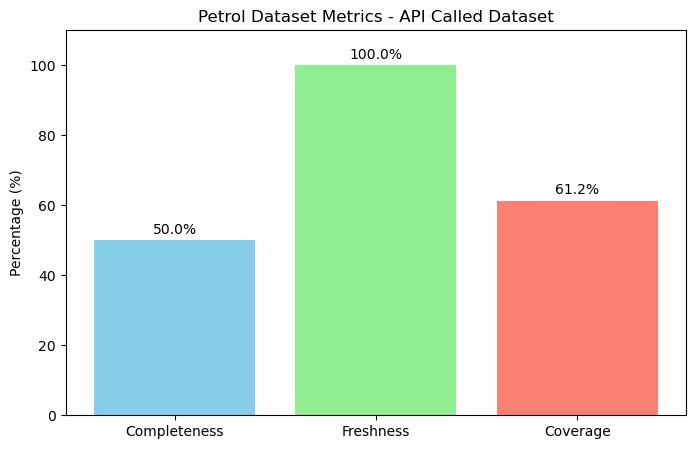

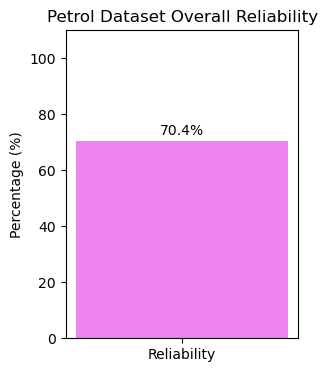

In [99]:
# Step 6: Bar plots visualisation
metrics_individual = ['Completeness', 'Freshness', 'Coverage']
values_individual  = [completeness_pct, fresh_pct, coverage_pct]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics_individual, values_individual, color=['skyblue','lightgreen','salmon'])
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Metrics - API Called Dataset')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

# --- Step 8: Bar plot for Reliability ---
plt.figure(figsize=(3,4))
bars = plt.bar(['Reliability'], [reliability_pct], color='violet')
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Overall Reliability')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

In [84]:
#Checking the Dataset obtained from Manual data generated

# Loading the data
df2 = pd.read_csv("../data/petrol_manual.csv")
df2.head(10)

,country,price_usd_per_liter,currency,last_updated,source_note
0,Norway,2.51,USD,2026-03-14,GlobalPetrolPrices.com
1,Netherlands,2.18,USD,2026-03-14,GlobalPetrolPrices.com
2,Denmark,2.09,USD,2026-03-14,GlobalPetrolPrices.com
3,Sweden,1.96,USD,2026-03-14,GlobalPetrolPrices.com
4,Finland,1.88,USD,2026-03-14,GlobalPetrolPrices.com
5,Switzerland,1.82,USD,2026-03-14,GlobalPetrolPrices.com
6,Italy,1.79,USD,2026-03-14,GlobalPetrolPrices.com
7,Spain,1.61,USD,2026-03-14,GlobalPetrolPrices.com
8,Portugal,1.57,USD,2026-03-14,GlobalPetrolPrices.com
9,South Korea,1.48,USD,2026-03-14,GlobalPetrolPrices.com


In [85]:
#Step 1 : Checking for completeness
COUNTRIES_EXPECTED = [
    "India", "USA", "UK", "Germany", "France", "Japan", "Australia", "Canada",
    "Brazil", "South Africa", "Pakistan", "China", "Russia", "Mexico",
    "Turkey", "Nigeria", "Indonesia", "Saudi Arabia", "UAE", "Egypt",
    "Norway", "Netherlands", "Denmark", "Sweden", "Finland", "Switzerland",
    "Italy", "Spain", "Portugal", "South Korea", "Thailand", "Vietnam",
    "Philippines", "Bangladesh", "Sri Lanka", "Argentina", "Iran",
    "Venezuela", "Libya", "Kazakhstan",
]

# Find missing countries
countries_in_data = df2['country'].tolist()
missing_countries = [c for c in COUNTRIES_EXPECTED if c not in countries_in_data]

print(f"Missing countries ({len(missing_countries)}): {missing_countries}")

# Number of countries present
countries_present = len(COUNTRIES_EXPECTED) - len(missing_countries)

# Percentage completeness
completeness_pct = (countries_present / len(COUNTRIES_EXPECTED)) * 100

print(f"Completeness: {countries_present} countries present ({completeness_pct:.2f}%)")

Missing countries (20): ['India', 'USA', 'UK', 'Germany', 'France', 'Japan', 'Australia', 'Canada', 'Brazil', 'South Africa', 'Pakistan', 'China', 'Russia', 'Mexico', 'Turkey', 'Nigeria', 'Indonesia', 'Saudi Arabia', 'UAE', 'Egypt']
Completeness: 20 countries present (50.00%)


In [86]:
#Step 2 : Checking for Freshness
from datetime import datetime, timedelta

# Define freshness threshold
FRESHNESS_DAYS = 7
NOW = datetime.now()
cutoff_date = NOW - timedelta(days=FRESHNESS_DAYS)

# Convert 'last_updated' to datetime
df2['last_updated_dt'] = pd.to_datetime(df2['last_updated'], errors='coerce')

# Count fresh vs stale records
fresh_records = df2[df2['last_updated_dt'] >= cutoff_date]
stale_records = df2[df2['last_updated_dt'] < cutoff_date]

# Percentage freshness
fresh_pct = (len(fresh_records) / len(df2)) * 100

print(f"Fresh records: {len(fresh_records)} / {len(df2)} ({fresh_pct:.2f}%)")
print(f"Stale records: {len(stale_records)} / {len(df2)} ({100 - fresh_pct:.2f}%)")

Fresh records: 20 / 20 (100.00%)
Stale records: 0 / 20 (0.00%)


In [87]:
# Step 3: Checking for Coverage (realistic)
import pandas as pd

COLUMNS = [
    "country",
    "iso2",
    "gasoline_usd_per_liter",
    "diesel_usd_per_liter",
    "currency",
    "last_updated",
    "source_note",
    "price_usd_per_liter",
]

coverage_percents = {}
for col in COLUMNS:
    if col in df2.columns:
        non_null_count = df2[col].notnull().sum()
        total_count    = len(df2)
        coverage_percents[col] = (non_null_count / total_count) * 100
    else:
        coverage_percents[col] = 0  # column missing entirely

# Overall coverage: average of all columns
coverage_pct = sum(coverage_percents.values()) / len(COLUMNS)

print("Coverage per column (%):")
for col, pct in coverage_percents.items():
    print(f"  {col}: {pct:.2f}%")

print(f"\nOverall coverage: {coverage_pct:.2f}%")

Coverage per column (%):
  country: 100.00%
  iso2: 0.00%
  gasoline_usd_per_liter: 0.00%
  diesel_usd_per_liter: 0.00%
  currency: 100.00%
  last_updated: 100.00%
  source_note: 100.00%
  price_usd_per_liter: 100.00%

Overall coverage: 62.50%


In [88]:
# Step 4: Reliability
reliability_pct = (completeness_pct + fresh_pct + coverage_pct) / 3

In [89]:
print(f"Completeness : {completeness_pct:.2f}%")
print(f"Freshness    : {fresh_pct:.2f}%")
print(f"Coverage     : {coverage_pct:.2f}%")
print(f"Reliability  : {reliability_pct:.2f}%")

Completeness : 50.00%
Freshness    : 100.00%
Coverage     : 62.50%
Reliability  : 70.83%


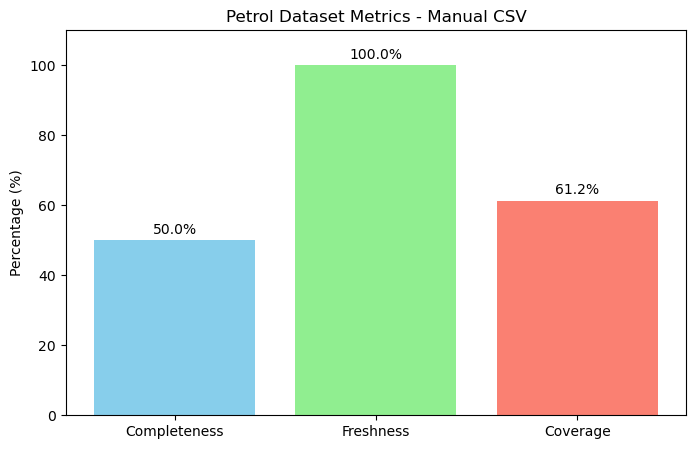

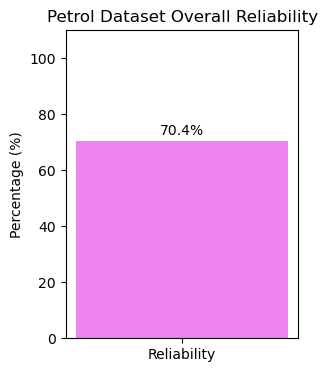

In [100]:
# Step 5: Bar plots visualisation
metrics_individual = ['Completeness', 'Freshness', 'Coverage']
values_individual  = [completeness_pct, fresh_pct, coverage_pct]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics_individual, values_individual, color=['skyblue','lightgreen','salmon'])
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Metrics - Manual CSV')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

# --- Step 8: Bar plot for Reliability ---
plt.figure(figsize=(3,4))
bars = plt.bar(['Reliability'], [reliability_pct], color='violet')
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Overall Reliability')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

In [91]:
#Checking the Dataset obtained through Web Scrapping

# Loading the data
df3 = pd.read_csv("../data/petrol_scraper.csv")
df3.head(10)

,country,price_usd_per_liter,currency,last_updated,source_note
0,India,1.10,USD,2026-03-16,GlobalPetrolPrices.com
1,USA,1.01,USD,2026-03-16,GlobalPetrolPrices.com
2,UK,1.82,USD,2026-03-16,GlobalPetrolPrices.com
3,Germany,2.36,USD,2026-03-16,GlobalPetrolPrices.com
4,France,2.08,USD,2026-03-16,GlobalPetrolPrices.com
5,Japan,1.00,USD,2026-03-16,GlobalPetrolPrices.com
6,Australia,1.31,USD,2026-03-16,GlobalPetrolPrices.com
7,Canada,1.30,USD,2026-03-16,GlobalPetrolPrices.com
8,Brazil,1.20,USD,2026-03-16,GlobalPetrolPrices.com
9,South Africa,1.22,USD,2026-03-16,GlobalPetrolPrices.com


In [92]:
#Step 1 : Checking for completeness
COUNTRIES_EXPECTED = [
    "India", "USA", "UK", "Germany", "France", "Japan", "Australia", "Canada",
    "Brazil", "South Africa", "Pakistan", "China", "Russia", "Mexico",
    "Turkey", "Nigeria", "Indonesia", "Saudi Arabia", "UAE", "Egypt",
    "Norway", "Netherlands", "Denmark", "Sweden", "Finland", "Switzerland",
    "Italy", "Spain", "Portugal", "South Korea", "Thailand", "Vietnam",
    "Philippines", "Bangladesh", "Sri Lanka", "Argentina", "Iran",
    "Venezuela", "Libya", "Kazakhstan",
]

# Find missing countries
countries_in_data = df3['country'].tolist()
missing_countries = [c for c in COUNTRIES_EXPECTED if c not in countries_in_data]

print(f"Missing countries ({len(missing_countries)}): {missing_countries}")

# Number of countries present
countries_present = len(COUNTRIES_EXPECTED) - len(missing_countries)

# Percentage completeness
completeness_pct = (countries_present / len(COUNTRIES_EXPECTED)) * 100

print(f"Completeness: {countries_present} countries present ({completeness_pct:.2f}%)")

Missing countries (20): ['Norway', 'Netherlands', 'Denmark', 'Sweden', 'Finland', 'Switzerland', 'Italy', 'Spain', 'Portugal', 'South Korea', 'Thailand', 'Vietnam', 'Philippines', 'Bangladesh', 'Sri Lanka', 'Argentina', 'Iran', 'Venezuela', 'Libya', 'Kazakhstan']
Completeness: 20 countries present (50.00%)


In [93]:
#Step 2 : Checking for Freshness
from datetime import datetime, timedelta

# Define freshness threshold
FRESHNESS_DAYS = 7
NOW = datetime.now()
cutoff_date = NOW - timedelta(days=FRESHNESS_DAYS)

# Convert 'last_updated' to datetime
df3['last_updated_dt'] = pd.to_datetime(df3['last_updated'], errors='coerce')

# Count fresh vs stale records
fresh_records = df3[df3['last_updated_dt'] >= cutoff_date]
stale_records = df3[df3['last_updated_dt'] < cutoff_date]

# Percentage freshness
fresh_pct = (len(fresh_records) / len(df3)) * 100

print(f"Fresh records: {len(fresh_records)} / {len(df3)} ({fresh_pct:.2f}%)")
print(f"Stale records: {len(stale_records)} / {len(df3)} ({100 - fresh_pct:.2f}%)")

Fresh records: 20 / 20 (100.00%)
Stale records: 0 / 20 (0.00%)


In [94]:
# Step 3: Checking for Coverage (realistic)
import pandas as pd

COLUMNS = [
    "country",
    "iso2",
    "gasoline_usd_per_liter",
    "diesel_usd_per_liter",
    "currency",
    "last_updated",
    "source_note",
    "price_usd_per_liter",
]

coverage_percents = {}
for col in COLUMNS:
    if col in df3.columns:
        non_null_count = df3[col].notnull().sum()
        total_count    = len(df3)
        coverage_percents[col] = (non_null_count / total_count) * 100
    else:
        coverage_percents[col] = 0  # column missing entirely

# Overall coverage: average of all columns
coverage_pct = sum(coverage_percents.values()) / len(COLUMNS)

print("Coverage per column (%):")
for col, pct in coverage_percents.items():
    print(f"  {col}: {pct:.2f}%")

print(f"\nOverall coverage: {coverage_pct:.2f}%")

Coverage per column (%):
  country: 100.00%
  iso2: 0.00%
  gasoline_usd_per_liter: 0.00%
  diesel_usd_per_liter: 0.00%
  currency: 100.00%
  last_updated: 100.00%
  source_note: 100.00%
  price_usd_per_liter: 90.00%

Overall coverage: 61.25%


In [95]:
# Step 4: Reliability
reliability_pct = (completeness_pct + fresh_pct + coverage_pct) / 3

In [96]:
print(f"Completeness : {completeness_pct:.2f}%")
print(f"Freshness    : {fresh_pct:.2f}%")
print(f"Coverage     : {coverage_pct:.2f}%")
print(f"Reliability  : {reliability_pct:.2f}%")

Completeness : 50.00%
Freshness    : 100.00%
Coverage     : 61.25%
Reliability  : 70.42%


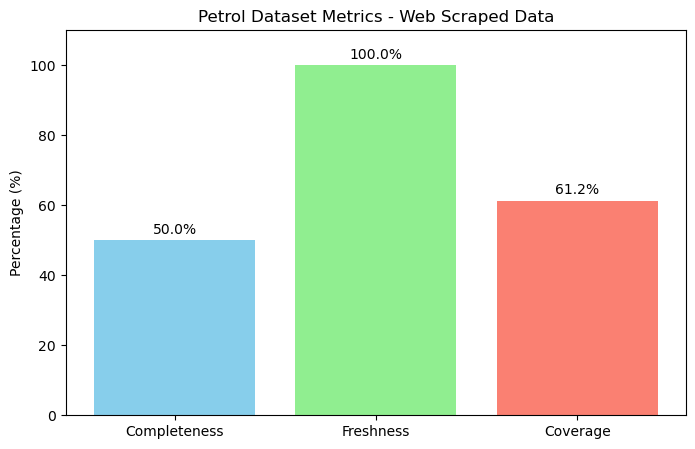

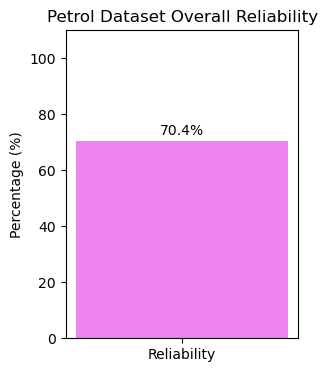

In [101]:
# Step 5: Bar plots visualisation
metrics_individual = ['Completeness', 'Freshness', 'Coverage']
values_individual  = [completeness_pct, fresh_pct, coverage_pct]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics_individual, values_individual, color=['skyblue','lightgreen','salmon'])
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Metrics - Web Scraped Data')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

# --- Step 8: Bar plot for Reliability ---
plt.figure(figsize=(3,4))
bars = plt.bar(['Reliability'], [reliability_pct], color='violet')
plt.ylim(0, 110)
plt.ylabel('Percentage (%)')
plt.title('Petrol Dataset Overall Reliability')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.show()

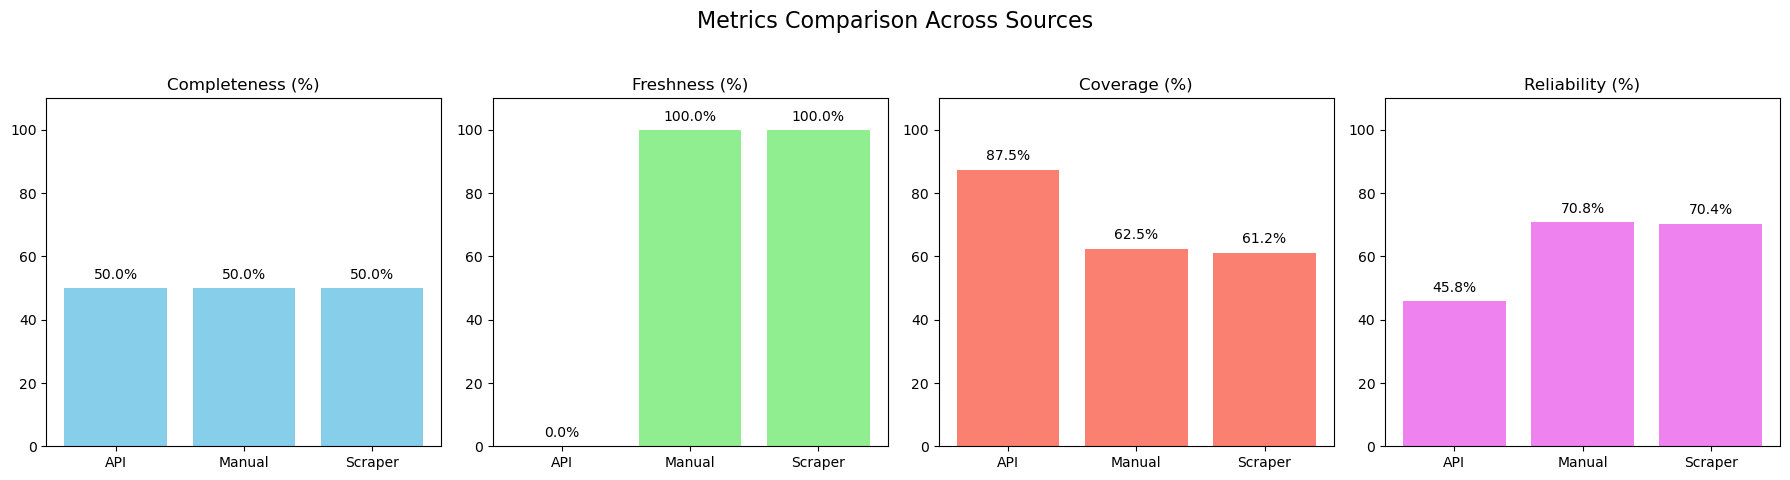


Conclusion: The dataset with the highest overall reliability is 'Manual'.


In [98]:
# --- Final Comparison of All Sources ---
records = [('API', '../data/worldbank_api.csv'), ('Manual', '../data/petrol_manual.csv'), ('Scraper', '../data/petrol_scraper.csv')]
results = []

for name, file in records:
    df = pd.read_csv(file)
    missing = [c for c in COUNTRIES_EXPECTED if c not in df['country'].tolist()]
    comp = (len(COUNTRIES_EXPECTED) - len(missing)) / len(COUNTRIES_EXPECTED) * 100
    
    df['last_updated_dt'] = pd.to_datetime(df['last_updated'], errors='coerce')
    cutoff = datetime.now() - timedelta(days=7)
    fresh = len(df[df['last_updated_dt'] >= cutoff]) / len(df) * 100 if len(df)>0 else 0
    
    cov = [df[col].notnull().sum() / len(df) * 100 if col in df.columns else 0 for col in COLUMNS]
    cov_pct = sum(cov) / len(COLUMNS)
    rel = (comp + fresh + cov_pct) / 3
    results.append((name, comp, fresh, cov_pct, rel))

# Plotting Comparison
names = [r[0] for r in results]
comps = [r[1] for r in results]
fresh = [r[2] for r in results]
covs = [r[3] for r in results]
rels = [r[4] for r in results]

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Metrics Comparison Across Sources', fontsize=16)

ax[0].bar(names, comps, color='skyblue')
ax[0].set_title('Completeness (%)')
ax[0].set_ylim(0, 110)

ax[1].bar(names, fresh, color='lightgreen')
ax[1].set_title('Freshness (%)')
ax[1].set_ylim(0, 110)

ax[2].bar(names, covs, color='salmon')
ax[2].set_title('Coverage (%)')
ax[2].set_ylim(0, 110)

ax[3].bar(names, rels, color='violet')
ax[3].set_title('Reliability (%)')
ax[3].set_ylim(0, 110)

for a in ax:
    for bar in a.patches:
        yval = bar.get_height()
        a.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}%', ha='center', va='bottom')
        
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# CONCLUSION
best_source = names[rels.index(max(rels))]
print(f"\nConclusion: The dataset with the highest overall reliability is '{best_source}'.")